In [1]:
import pandas as pd
import numpy as np 
import networkx as nx 
import matplotlib.pyplot as plt 
import yfinance as yf 


In [2]:
sp500_tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B",
    "JPM", "JNJ", "V", "UNH", "XOM", "PG", "MA", "HD", "CVX", "MRK",
    "ABBV", "PEP", "KO", "AVGO", "COST", "MCD", "WMT", "BAC", "CRM",
    "ACN", "LLY", "TMO", "CSCO", "ABT", "NKE", "NEE", "DHR", "TXN",
    "ORCL", "PM", "MS", "RTX", "AMGN", "HON", "UPS", "QCOM", "IBM",
    "GS", "CAT", "SBUX", "BA", "GE"
]
crypto_tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]
all_tickers = sp500_tickers + crypto_tickers

raw = yf.download(all_tickers, start="2019-01-01", end="2024-12-31", auto_adjust=True)
prices = raw.xs("Close", axis=1, level="Price")
prices = prices.dropna(how="all")
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))
returns = np.log(prices / prices.shift(1)).dropna(how="all")
corr_matrix = returns.corr()

threshold = 0.5
G = nx.Graph()
G.add_nodes_from(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        asset_i = corr_matrix.columns[i]
        asset_j = corr_matrix.columns[j]
        correlation = corr_matrix.loc[asset_i, asset_j]
        if correlation > threshold:
            G.add_edge(asset_i, asset_j, weight=correlation)

print(f"Network ready — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

[*********************100%***********************]  55 of 55 completed


Network ready — 55 nodes, 242 edges


Compute the three centrality measures

In [4]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight", normalized=True)
eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)

centrality_df = pd.DataFrame({
    "degree": degree_centrality,
    "betweenness": betweenness_centrality,
    "eigenvector": eigenvector_centrality,
}).sort_values("degree", ascending=False)

print(centrality_df.round(4).head(15))

       degree  betweenness  eigenvector
BRK-B  0.5000       0.0769       0.3147
ACN    0.4259       0.0776       0.2467
HON    0.4074       0.0433       0.2773
MA     0.3889       0.0335       0.2557
MSFT   0.3704       0.0622       0.1787
MS     0.3519       0.0056       0.2689
V      0.3519       0.0231       0.2462
HD     0.3333       0.0363       0.2134
GS     0.3333       0.0063       0.2601
TXN    0.3333       0.0419       0.2109
BAC    0.3148       0.0224       0.2489
AAPL   0.2963       0.0294       0.1525
JPM    0.2963       0.0070       0.2398
NVDA   0.2037       0.0154       0.0924
RTX    0.2037       0.0035       0.1613


-   We can see that BRK-B (Berkshire Hathaway) sits at the top because they own positions across financials, consumer goods, energy and tech. It's essentially a mini-index of the whole economy. So it makes sense that it correlates highly with the largest number of sectors simultaneously (it is the market in many ways).
-   ACN (Accenture) ranks second, but again it makes sense because it is a consulting firm that works across sectors (financial, services, healthcare, energy, tech). So its revenue is tied to the health of the entire corporate world, not one sector, so it moves with everyone.
The same logic applies for the others.
-   MS (Morgan Stanley) has a very low betweenness (0.0056) despite its high degree. This means MS is connected to many nodes but doesn't sit on critital paths between different paths of the network.

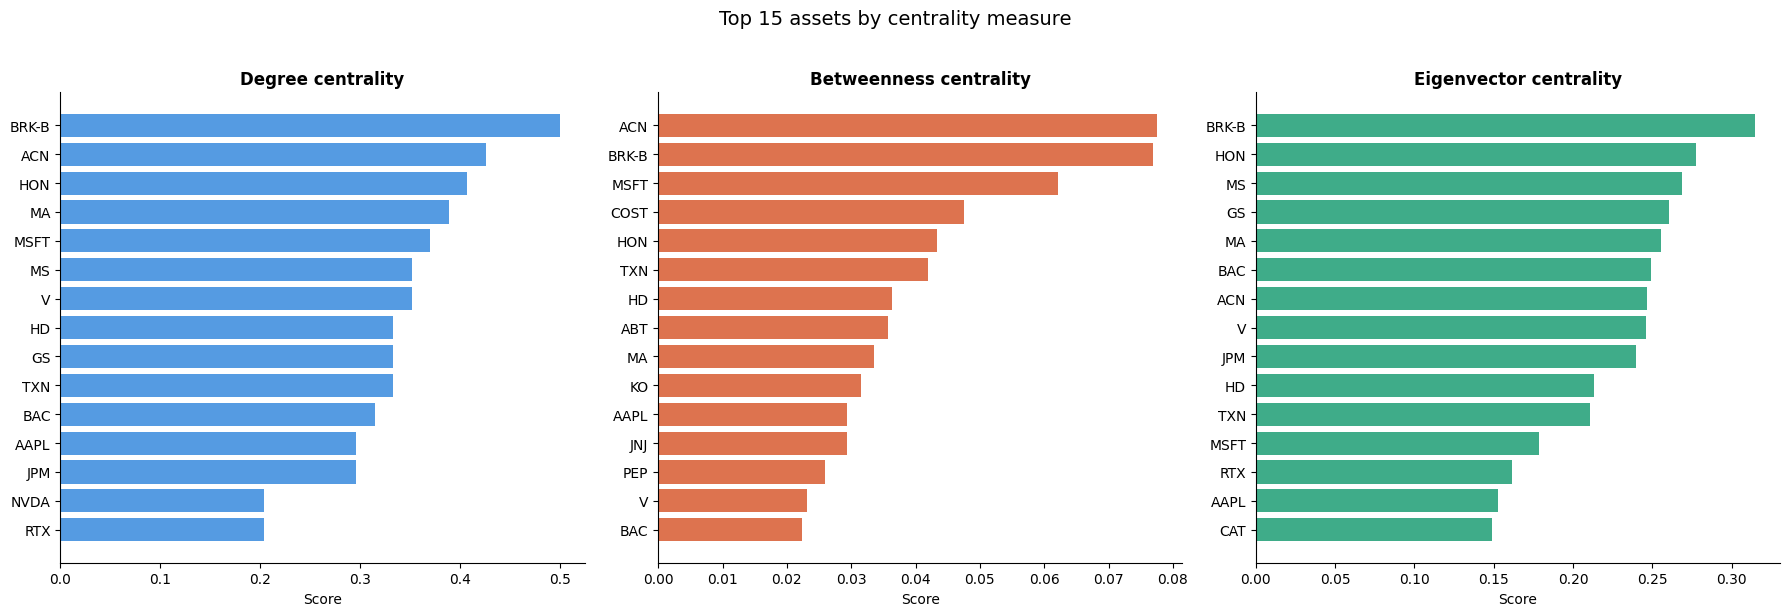

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


metrics = ["degree", "betweenness", "eigenvector"]
titles = ["Degree centrality", "Betweenness centrality", "Eigenvector centrality"]
colors = ["#378ADD", "#D85A30", "#1D9E75"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    data = centrality_df[metric].sort_values(ascending=False).head(15)
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Score", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Top 15 assets by centrality measure", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("centrality_measure.png", dpi=150)
plt.show()


Before going on with interpretation, let's make clear first what are the different metrics :
-   Degree : how many connections the particular node has with respect to how many connections are actually possible for it
-   Betweenness : how many times this particular nodes happens to be in the shortest path bewteen any two other nodes. Shortest path can mean to just consider path with the "fewer edges". But in this case shortest path is instead the path with the highest "total correlation". It can be interpreted as "how often the node lies on the most correlated path between two other nodes". High bewteenness can be seen as a contagion bridge. If it crashes, the shock will travel through it to other nodes. It is most dangerous to hold because it connects separate parts of the market. 
-   Eigenvector centrality : the intuition here is how important are the nodes you are connected to. Being recommended by a CEO matters more than 10 recommendations from interns. A node is powerful if its neighors are powerful and its neighors are powerful if their neighors are powerful. Powerful translates as "deeply embeded in the market's core risk factor". GS scores high not because it has many connections, but because its neighbors (ACN, BRK-B, HON) are themselves central to how the whole market moves together.